# Founder Fade Curves OSS Survival Experiment

This notebook demonstrates a comparative experiment evaluating whether temporal fade curve descriptors of founder involvement outperform static project metrics in predicting OSS project survival.

**What this artifact does:**
- Creates synthetic dataset of OSS projects with varied founder fade patterns
- Computes 6 fade descriptors: linear slope, convexity, decline onset time, cliff score, plateau indicator, and composite fade index
- Trains 4 models comparing static-only, fade-only, and combined feature sets
- Uses stratified 5-fold cross-validation with AUC-ROC, Log-Loss, and R² metrics
- Runs falsification control by shuffling fade features to confirm genuine signal

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import json
import sys
import warnings
import os
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
from loguru import logger
from scipy.signal import savgol_filter
from scipy.stats import pointbiserialr
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import log_loss, r2_score, roc_auc_score
from sklearn.model_selection import KFold, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=RuntimeWarning)

# Setup logging (simplified for notebook)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss} | {level:<7} | {message}")
logger.add("demo_run.log", rotation="5 MB", level="DEBUG")

2

In [3]:
# Load the mini demo data
import json
import os

def load_data():
    # Try to load from local file first (for demo)
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    # Fallback to GitHub URL
    GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-ad55a2-founder-fade-curve-predicts-oss-survival/main/round-1/experiment-1/demo/mini_demo_data.json"
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception as e:
        raise FileNotFoundError(f"Could not load mini_demo_data.json: {e}")

In [4]:
import os
data = load_data()
print(f"Loaded {len(data['examples'])} projects")

Loaded 8 projects


## Configuration

Tunable parameters for the experiment. Start with minimum values and scale up as needed.

In [5]:
# EXPERIMENT CONFIGURATION
CV_FOLDS = 3                    # Number of cross-validation folds (reduced for small dataset)
C_PARAM = 1.0                   # Logistic regression regularization inverse
MAX_ITER = 1000                 # Maximum iterations for model convergence
RIDGE_ALPHA = 1.0               # Ridge regression regularization
RANDOM_STATE = 42               # Random seed for reproducibility
CLASS_WEIGHT = "balanced"       # Handle class imbalance
N_REPEATS = 3                   # Permutation importance repeats (reduced for speed)
RANDOM_SEED_SHUFFLE = 123       # Seed for falsification control

## Data Loading and Validation

Parse the raw JSON data into static features (project metadata at founder departure) and time-series data (monthly founder involvement shares).

In [6]:
def load_and_validate(data):
    """Load and validate the dataset, returning static and time-series DataFrames."""
    examples = data.get("examples", [])
    print(f"Loaded {len(examples)} projects")
    
    # Build static features DataFrame
    static_rows = []
    timeseries_rows = []
    
    for ex in examples:
        project_id = ex["project_id"]
        static = ex["static_features_at_departure"]
        
        static_row = {
            "project_id": project_id,
            "founder_id": ex["founder_id"],
            "departure_date": ex["departure_date"],
            "is_survived": int(ex["survival_label"]),
            "bus_factor": static["bus_factor_at_departure"],
            "contributor_count": static["contributor_count"],
            "project_age": static["repo_age_days"] / 365.25,  # in years
            "stars": static["stars"],
            "file_count": static["file_count"],
        }
        
        # Post-departure activity (continuous target)
        post_commits = ex["post_departure_metrics"]["total_monthly_commits"]
        post_departure_activity = float(np.mean(post_commits))
        static_row["post_departure_activity"] = post_departure_activity
        
        static_rows.append(static_row)
        
        # Time-series data
        for m in ex["pre_departure_metrics"]:
            # Combined share: average of commit, merge, review shares
            combined = np.mean([
                m["founder_commit_share"],
                m["founder_merge_share"],
                m["founder_review_share"]
            ])
            timeseries_rows.append({
                "project_id": project_id,
                "month_index": m["month_index"],
                "founder_commit_share": m["founder_commit_share"],
                "founder_merge_share": m["founder_merge_share"],
                "founder_review_share": m["founder_review_share"],
                "combined_share": combined,
                "total_monthly_commits": m["total_monthly_commits"],
                "total_monthly_merges": m["total_monthly_merges"],
            })
    
    df_static = pd.DataFrame(static_rows)
    df_ts = pd.DataFrame(timeseries_rows)
    
    print(f"Static shape: {df_static.shape}, Time-series shape: {df_ts.shape}")
    print(f"Survival distribution: {df_static['is_survived'].value_counts().to_dict()}")
    
    # Validate
    assert df_static["project_id"].nunique() == len(df_static), "Duplicate project_ids"
    assert df_ts["project_id"].isin(df_static["project_id"]).all(), "TS project_ids not in static"
    assert df_static["is_survived"].notna().all(), "Missing survival labels"
    
    return df_static, df_ts

df_static, df_ts = load_and_validate(data)

Loaded 8 projects
Static shape: (8, 10), Time-series shape: (260, 8)
Survival distribution: {0: 4, 1: 4}


## Fade Curve Descriptor Computation

For each project, compute 6 quantitative descriptors capturing the founder involvement fade pattern:
- **slope**: Linear trend of founder combined share over time
- **convexity**: Mean second derivative (acceleration/deceleration)
- **decline_start**: Month index where sustained decline begins
- **cliff_score**: Ratio of recent drop to prior average activity
- **is_plateau**: Binary indicator of plateau-then-cliff pattern
- **fade_idx**: Composite index (0=sudden drop, 1=smooth decline)

In [7]:
def compute_descriptors(group: pd.DataFrame) -> pd.Series:
    """
    Compute fade curve descriptors for a single project's time-series.
    
    Returns: slope, convexity, decline_start, cliff_score, is_plateau, fade_idx
    """
    # Sort by month_index
    group = group.sort_values("month_index")
    
    t = group["month_index"].values.astype(float)
    y = group["combined_share"].values.astype(float)
    
    n = len(y)
    if n < 3:
        # Too little data - return defaults
        return pd.Series({
            "slope": 0.0,
            "convexity": 0.0,
            "decline_start": 0,
            "cliff_score": 0.0,
            "is_plateau": 0,
            "fade_idx": 0.5
        })
    
    # Step A: Denoising with Savitzky-Golay
    window_length = min(5, n // 2 * 2 - 1) or 3
    if window_length % 2 == 0:
        window_length -= 1
    window_length = max(3, window_length)
    
    try:
        y_smooth = savgol_filter(y, window_length=window_length, polyorder=min(2, window_length - 1))
    except ValueError:
        y_smooth = y.copy()
    
    # Descriptor 1: Linear Slope (S_slope)
    try:
        slope, _ = np.polyfit(t, y_smooth, 1)
    except np.linalg.LinAlgError:
        slope = 0.0
    
    # Descriptor 2: Curvature/Convexity (S_convex)
    # Mean of second derivative
    try:
        first_deriv = np.gradient(y_smooth)
        second_deriv = np.gradient(first_deriv)
        convexity = float(np.mean(second_deriv))
    except Exception:
        convexity = 0.0
    
    # Descriptor 3: Time-to-Onset-of-Decline (S_decline_start)
    # First index where derivative is consistently negative
    try:
        deriv = np.gradient(y_smooth)
        decline_indices = np.where(deriv < -0.01)[0]
        decline_start = int(decline_indices[0]) if len(decline_indices) > 0 else n
    except Exception:
        decline_start = n
    
    # Descriptor 4: Abrupt-Cliff Indicator (S_cliff)
    # Ratio of final 2-month drop to average of prior 6 months
    if n > 8:
        recent_avg = float(np.mean(y_smooth[-8:-2]))
        final_drop = recent_avg - float(np.mean(y_smooth[-2:]))
        cliff_score = max(0.0, final_drop / (recent_avg + 1e-6))
    else:
        cliff_score = 0.0
    
    # Descriptor 5: Plateau-then-Cliff (S_plateau)
    is_plateau = 0
    if len(decline_indices) > 0 and n > 10:
        idx = decline_indices[0]
        if idx > 5:
            plateau_variance = float(np.var(y_smooth[idx-5:idx]))
            total_variance = float(np.var(y_smooth))
            if plateau_variance < total_variance * 0.5 and total_variance > 0:
                is_plateau = 1
    
    # Descriptor 6: Composite Fade Index (S_fade_idx)
    # 1.0 = perfect linear smooth decline, 0.0 = sudden drop
    fade_idx = np.clip(1.0 - cliff_score + (0.5 if slope < 0 else 0), 0, 1)
    
    return pd.Series({
        "slope": float(slope),
        "convexity": float(convexity),
        "decline_start": float(decline_start),
        "cliff_score": float(cliff_score),
        "is_plateau": float(is_plateau),
        "fade_idx": float(fade_idx)
    })

# Compute descriptors for all projects
features_fade = df_ts.groupby("project_id").apply(compute_descriptors, include_groups=False)
features_fade = features_fade.reset_index()
df_final = df_static.merge(features_fade, on="project_id")
print(f"Merged dataset shape: {df_final.shape}")

Merged dataset shape: (8, 16)


## Model Training and Evaluation

Train and evaluate 4 models using stratified 5-fold cross-validation:
- **Model A**: Static features only (baseline)
- **Model B**: Fade descriptors only (hypothesis)
- **Model C**: Combined features (static + fade)
- **Model D**: Ridge regression for continuous post-departure activity prediction

In [8]:
def run_experiment(df_static: pd.DataFrame, df_ts: pd.DataFrame) -> dict[str, Any]:
    """Run the full experiment pipeline."""
    
    features_fade = df_ts.groupby("project_id").apply(compute_descriptors, include_groups=False)
    features_fade = features_fade.reset_index()
    
    df_final = df_static.merge(features_fade, on="project_id")
    print(f"Merged dataset shape: {df_final.shape}")
    
    # Check for NaN values
    print(f"NaN counts:\n{df_final.isna().sum()}")
    df_final = df_final.fillna(0)
    
    # Define feature sets
    static_features = ["bus_factor", "contributor_count", "project_age", "stars", "file_count"]
    fade_features = ["slope", "convexity", "decline_start", "cliff_score", "is_plateau", "fade_idx"]
    all_features = static_features + fade_features
    
    X_static = df_final[static_features].values
    X_fade = df_final[fade_features].values
    X_combined = df_final[all_features].values
    
    y_binary = df_final["is_survived"].values
    y_continuous = df_final["post_departure_activity"].values
    
    print(f"Class balance: {np.bincount(y_binary)}")
    
    # Standardize features
    scaler_static = StandardScaler()
    scaler_fade = StandardScaler()
    scaler_combined = StandardScaler()
    
    X_static_scaled = scaler_static.fit_transform(X_static)
    X_fade_scaled = scaler_fade.fit_transform(X_fade)
    X_combined_scaled = scaler_combined.fit_transform(X_combined)
    
    # Cross-validation setup
    cv_binary = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    cv_continuous = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    
    results = {}
    
    # --- Model A: Baseline (Static Only) - Logistic Regression ---
    print("Training Model A: Static Only (Logistic Regression)")
    model_a = LogisticRegression(penalty="l2", C=C_PARAM, max_iter=MAX_ITER, random_state=RANDOM_STATE, class_weight=CLASS_WEIGHT)
    cv_a = cross_validate(
        model_a, X_static_scaled, y_binary,
        cv=cv_binary, scoring=["roc_auc", "neg_log_loss"],
        return_estimator=True, n_jobs=-1
    )
    results["model_a_auc"] = float(np.mean(cv_a["test_roc_auc"]))
    results["model_a_auc_std"] = float(np.std(cv_a["test_roc_auc"]))
    results["model_a_logloss"] = float(-np.mean(cv_a["test_neg_log_loss"]))
    results["model_a_logloss_std"] = float(np.std(cv_a["test_neg_log_loss"]))
    print(f"  AUC: {results['model_a_auc']:.4f} ± {results['model_a_auc_std']:.4f}")
    
    # Get per-fold predictions for Model A
    model_a_probs = []
    for fold_idx, (train_idx, test_idx) in enumerate(cv_binary.split(X_static_scaled, y_binary)):
        model_a.fit(X_static_scaled[train_idx], y_binary[train_idx])
        probs = model_a.predict_proba(X_static_scaled[test_idx])[:, 1]
        for i, idx in enumerate(test_idx):
            model_a_probs.append((idx, probs[i], fold_idx))
    
    # R2 for continuous (Ridge)
    model_a_cont = Ridge(alpha=RIDGE_ALPHA, random_state=RANDOM_STATE)
    cv_a_cont = cross_validate(
        model_a_cont, X_static_scaled, y_continuous,
        cv=cv_continuous, scoring="r2", return_estimator=True, n_jobs=-1
    )
    results["model_a_r2"] = float(np.mean(cv_a_cont["test_score"]))
    results["model_a_r2_std"] = float(np.std(cv_a_cont["test_score"]))
    print(f"  R2: {results['model_a_r2']:.4f} ± {results['model_a_r2_std']:.4f}")
    
    # --- Model B: Hypothesis (Fade Only) - Logistic Regression ---
    print("Training Model B: Fade Only (Logistic Regression)")
    model_b = LogisticRegression(penalty="l2", C=C_PARAM, max_iter=MAX_ITER, random_state=RANDOM_STATE, class_weight=CLASS_WEIGHT)
    cv_b = cross_validate(
        model_b, X_fade_scaled, y_binary,
        cv=cv_binary, scoring=["roc_auc", "neg_log_loss"],
        return_estimator=True, n_jobs=-1
    )
    results["model_b_auc"] = float(np.mean(cv_b["test_roc_auc"]))
    results["model_b_auc_std"] = float(np.std(cv_b["test_roc_auc"]))
    results["model_b_logloss"] = float(-np.mean(cv_b["test_neg_log_loss"]))
    results["model_b_logloss_std"] = float(np.std(cv_b["test_neg_log_loss"]))
    print(f"  AUC: {results['model_b_auc']:.4f} ± {results['model_b_auc_std']:.4f}")
    
    # Get per-fold predictions for Model B
    model_b_probs = []
    for fold_idx, (train_idx, test_idx) in enumerate(cv_binary.split(X_fade_scaled, y_binary)):
        model_b.fit(X_fade_scaled[train_idx], y_binary[train_idx])
        probs = model_b.predict_proba(X_fade_scaled[test_idx])[:, 1]
        for i, idx in enumerate(test_idx):
            model_b_probs.append((idx, probs[i], fold_idx))
    
    model_b_cont = Ridge(alpha=RIDGE_ALPHA, random_state=RANDOM_STATE)
    cv_b_cont = cross_validate(
        model_b_cont, X_fade_scaled, y_continuous,
        cv=cv_continuous, scoring="r2", return_estimator=True, n_jobs=-1
    )
    results["model_b_r2"] = float(np.mean(cv_b_cont["test_score"]))
    results["model_b_r2_std"] = float(np.std(cv_b_cont["test_score"]))
    print(f"  R2: {results['model_b_r2']:.4f} ± {results['model_b_r2_std']:.4f}")
    
    # --- Model C: Combined - Logistic Regression ---
    print("Training Model C: Combined (Logistic Regression)")
    model_c = LogisticRegression(penalty="l2", C=C_PARAM, max_iter=MAX_ITER, random_state=RANDOM_STATE, class_weight=CLASS_WEIGHT)
    cv_c = cross_validate(
        model_c, X_combined_scaled, y_binary,
        cv=cv_binary, scoring=["roc_auc", "neg_log_loss"],
        return_estimator=True, n_jobs=-1
    )
    results["model_c_auc"] = float(np.mean(cv_c["test_roc_auc"]))
    results["model_c_auc_std"] = float(np.std(cv_c["test_roc_auc"]))
    results["model_c_logloss"] = float(-np.mean(cv_c["test_neg_log_loss"]))
    results["model_c_logloss_std"] = float(np.std(cv_c["test_neg_log_loss"]))
    print(f"  AUC: {results['model_c_auc']:.4f} ± {results['model_c_auc_std']:.4f}")
    
    # Get per-fold predictions for Model C
    model_c_probs = []
    for fold_idx, (train_idx, test_idx) in enumerate(cv_binary.split(X_combined_scaled, y_binary)):
        model_c.fit(X_combined_scaled[train_idx], y_binary[train_idx])
        probs = model_c.predict_proba(X_combined_scaled[test_idx])[:, 1]
        for i, idx in enumerate(test_idx):
            model_c_probs.append((idx, probs[i], fold_idx))
    
    model_c_cont = Ridge(alpha=RIDGE_ALPHA, random_state=RANDOM_STATE)
    cv_c_cont = cross_validate(
        model_c_cont, X_combined_scaled, y_continuous,
        cv=cv_continuous, scoring="r2", return_estimator=True, n_jobs=-1
    )
    results["model_c_r2"] = float(np.mean(cv_c_cont["test_score"]))
    results["model_c_r2_std"] = float(np.std(cv_c_cont["test_score"]))
    print(f"  R2: {results['model_c_r2']:.4f} ± {results['model_c_r2_std']:.4f}")
    
    # --- Feature Importance (Permutation Importance on Combined Model) ---
    print("Computing permutation importance...")
    model_c.fit(X_combined_scaled, y_binary)
    
    perm_importance = permutation_importance(
        model_c, X_combined_scaled, y_binary,
        n_repeats=N_REPEATS, random_state=RANDOM_STATE, n_jobs=-1,
        scoring="roc_auc"
    )
    
    importance_dict = dict(zip(all_features, perm_importance.importances_mean.tolist()))
    
    fade_importance = {k: v for k, v in importance_dict.items() if k in fade_features}
    static_importance = {k: v for k, v in importance_dict.items() if k in static_features}
    
    results["feature_importance"] = {
        "fade_descriptors": fade_importance,
        "static_descriptors": static_importance
    }
    print(f"  Fade importance: {fade_importance}")
    print(f"  Static importance: {static_importance}")
    
    # --- Directionality: Correlation between fade_idx and survival ---
    fade_idx_values = df_final["fade_idx"].values
    corr, p_val = pointbiserialr(fade_idx_values, y_binary)
    direction = "Positive" if corr > 0 else "Negative"
    results["directionality"] = f"{direction} correlation between fade_idx and survival (r={corr:.3f}, p={p_val:.3f})"
    print(f"  Directionality: {results['directionality']}")
    
    # --- Falsification Control ---
    print("Running falsification control...")
    np.random.seed(RANDOM_SEED_SHUFFLE)
    X_fade_shuffled = X_fade_scaled.copy()
    for col in range(X_fade_shuffled.shape[1]):
        np.random.shuffle(X_fade_shuffled[:, col])
    
    model_control = LogisticRegression(penalty="l2", C=C_PARAM, max_iter=MAX_ITER, random_state=RANDOM_STATE, class_weight=CLASS_WEIGHT)
    cv_control = cross_validate(
        model_control, X_fade_shuffled, y_binary,
        cv=cv_binary, scoring="roc_auc", n_jobs=-1
    )
    control_auc = float(np.mean(cv_control["test_score"]))
    
    auc_diff = results["model_b_auc"] - control_auc
    if auc_diff > 0.05 and results["model_b_auc"] > control_auc:
        falsification = f"Significant: Fade AUC ({results['model_b_auc']:.3f}) > Control AUC ({control_auc:.3f}), diff={auc_diff:.3f}"
    else:
        falsification = f"Not significant: Fade AUC ({results['model_b_auc']:.3f}) vs Control AUC ({control_auc:.3f}), diff={auc_diff:.3f}"
    
    results["falsification_result"] = falsification
    print(f"  Falsification: {falsification}")
    
    # --- Additional: Model D - Continuous Activity Predictor ---
    print("Training Model D: Continuous Activity (Ridge)")
    model_d = Ridge(alpha=RIDGE_ALPHA, random_state=RANDOM_STATE)
    cv_d = cross_validate(
        model_d, X_combined_scaled, y_continuous,
        cv=cv_continuous, scoring="r2", return_estimator=True, n_jobs=-1
    )
    results["model_d_r2"] = float(np.mean(cv_d["test_score"]))
    results["model_d_r2_std"] = float(np.std(cv_d["test_score"]))
    print(f"  R2: {results['model_d_r2']:.4f} ± {results['model_d_r2_std']:.4f}")
    
    model_d_static = Ridge(alpha=RIDGE_ALPHA, random_state=RANDOM_STATE)
    cv_d_static = cross_validate(
        model_d_static, X_static_scaled, y_continuous,
        cv=cv_continuous, scoring="r2", n_jobs=-1
    )
    results["model_d_static_r2"] = float(np.mean(cv_d_static["test_score"]))
    results["model_d_static_r2_std"] = float(np.std(cv_d_static["test_score"]))
    
    model_d_fade = Ridge(alpha=RIDGE_ALPHA, random_state=RANDOM_STATE)
    cv_d_fade = cross_validate(
        model_d_fade, X_fade_scaled, y_continuous,
        cv=cv_continuous, scoring="r2", n_jobs=-1
    )
    results["model_d_fade_r2"] = float(np.mean(cv_d_fade["test_score"]))
    results["model_d_fade_r2_std"] = float(np.std(cv_d_fade["test_score"]))
    
    # Prepare examples for exp_gen_sol_out schema
    prob_dict_a = {idx: (prob, fold) for idx, prob, fold in model_a_probs}
    prob_dict_b = {idx: (prob, fold) for idx, prob, fold in model_b_probs}
    prob_dict_c = {idx: (prob, fold) for idx, prob, fold in model_c_probs}
    
    examples = []
    for idx in range(len(df_final)):
        project_id = df_final.iloc[idx]["project_id"]
        true_label = int(df_final.iloc[idx]["is_survived"])
        
        prob_a, fold_a = prob_dict_a.get(idx, (0.5, -1))
        prob_b, fold_b = prob_dict_b.get(idx, (0.5, -1))
        prob_c, fold_c = prob_dict_c.get(idx, (0.5, -1))
        
        pred_a = "survive" if prob_a > 0.5 else "collapse"
        pred_b = "survive" if prob_b > 0.5 else "collapse"
        pred_c = "survive" if prob_c > 0.5 else "collapse"
        
        input_data = {
            "project_id": project_id,
            "static_features": {
                "bus_factor": float(df_final.iloc[idx]["bus_factor"]),
                "contributor_count": float(df_final.iloc[idx]["contributor_count"]),
                "project_age": float(df_final.iloc[idx]["project_age"]),
                "stars": float(df_final.iloc[idx]["stars"]),
                "file_count": float(df_final.iloc[idx]["file_count"])
            },
            "fade_descriptors": {
                "slope": float(df_final.iloc[idx]["slope"]),
                "convexity": float(df_final.iloc[idx]["convexity"]),
                "decline_start": float(df_final.iloc[idx]["decline_start"]),
                "cliff_score": float(df_final.iloc[idx]["cliff_score"]),
                "is_plateau": float(df_final.iloc[idx]["is_plateau"]),
                "fade_idx": float(df_final.iloc[idx]["fade_idx"])
            }
        }
        
        output_data = {
            "survival": "survive" if true_label == 1 else "collapse",
            "post_departure_activity": float(df_final.iloc[idx]["post_departure_activity"])
        }
        
        example = {
            "input": json.dumps(input_data),
            "output": json.dumps(output_data),
            "metadata_fold": int(fold_a) if fold_a >= 0 else 0,
            "metadata_feature_names": ",".join(all_features),
            "predict_baseline_static": pred_a,
            "predict_fade_only": pred_b,
            "predict_combined": pred_c,
            "predict_baseline_static_prob": f"{prob_a:.4f}",
            "predict_fade_only_prob": f"{prob_b:.4f}",
            "predict_combined_prob": f"{prob_c:.4f}"
        }
        examples.append(example)
    
    dataset_output = {
        "metadata": {
            "method_name": "founder_fade_curves_experiment",
            "description": "Testing Founder Fade Curves as Predictors of OSS Survival",
            "n_projects": len(df_final),
            "n_survived": int(np.sum(y_binary)),
            "n_collapsed": int(np.sum(1 - y_binary)),
            "cv_folds": CV_FOLDS,
            "metrics": {
                "model_a_auc": results["model_a_auc"],
                "model_a_auc_std": results["model_a_auc_std"],
                "model_b_auc": results["model_b_auc"],
                "model_b_auc_std": results["model_b_auc_std"],
                "model_c_auc": results["model_c_auc"],
                "model_c_auc_std": results["model_c_auc_std"],
                "model_a_r2": results["model_a_r2"],
                "model_b_r2": results["model_b_r2"],
                "model_c_r2": results["model_c_r2"],
                "model_d_r2": results["model_d_r2"]
            },
            "feature_importance": results["feature_importance"],
            "directionality": results["directionality"],
            "falsification_result": results["falsification_result"]
        },
        "datasets": [
            {
                "dataset": "oss_founder_fade_survival",
                "examples": examples
            }
        ]
    }
    
    return dataset_output

# Run the experiment
output = run_experiment(df_static, df_ts)

Merged dataset shape: (8, 16)
NaN counts:
project_id                 0
founder_id                 0
departure_date             0
is_survived                0
bus_factor                 0
contributor_count          0
project_age                0
stars                      0
file_count                 0
post_departure_activity    0
slope                      0
convexity                  0
decline_start              0
cliff_score                0
is_plateau                 0
fade_idx                   0
dtype: int64
Class balance: [4 4]
Training Model A: Static Only (Logistic Regression)


  AUC: 1.0000 ± 0.0000
  R2: -120.0287 ± 170.0799
Training Model B: Fade Only (Logistic Regression)
  AUC: 0.8333 ± 0.2357
  R2: -1673.0284 ± 2364.6320
Training Model C: Combined (Logistic Regression)
  AUC: 1.0000 ± 0.0000
  R2: -1010.4864 ± 1429.8783
Computing permutation importance...
  Fade importance: {'slope': 0.0, 'convexity': 0.0, 'decline_start': 0.0, 'cliff_score': 0.0, 'is_plateau': 0.0, 'fade_idx': 0.0}
  Static importance: {'bus_factor': 0.0, 'contributor_count': 0.0, 'project_age': 0.0, 'stars': 0.041666666666666664, 'file_count': 0.0}
  Directionality: Positive correlation between fade_idx and survival (r=0.712, p=0.047)
Running falsification control...


  Falsification: Not significant: Fade AUC (0.833) vs Control AUC (1.000), diff=-0.167
Training Model D: Continuous Activity (Ridge)
  R2: -1010.4864 ± 1429.8783


## Results Visualization

Display key experimental results: model performance metrics, feature importance, and example predictions.


EXPERIMENT RESULTS SUMMARY
Total projects: 8
Survived: 4, Collapsed: 4
Model A (Static Only)    AUC: 1.0000 ± 0.0000
Model B (Fade Only)      AUC: 0.8333 ± 0.2357
Model C (Combined)       AUC: 1.0000 ± 0.0000
Model D (Continuous)     R2:  -1010.4864
------------------------------------------------------------
Directionality: Positive correlation between fade_idx and survival (r=0.712, p=0.047)
Falsification: Not significant: Fade AUC (0.833) vs Control AUC (1.000), diff=-0.167


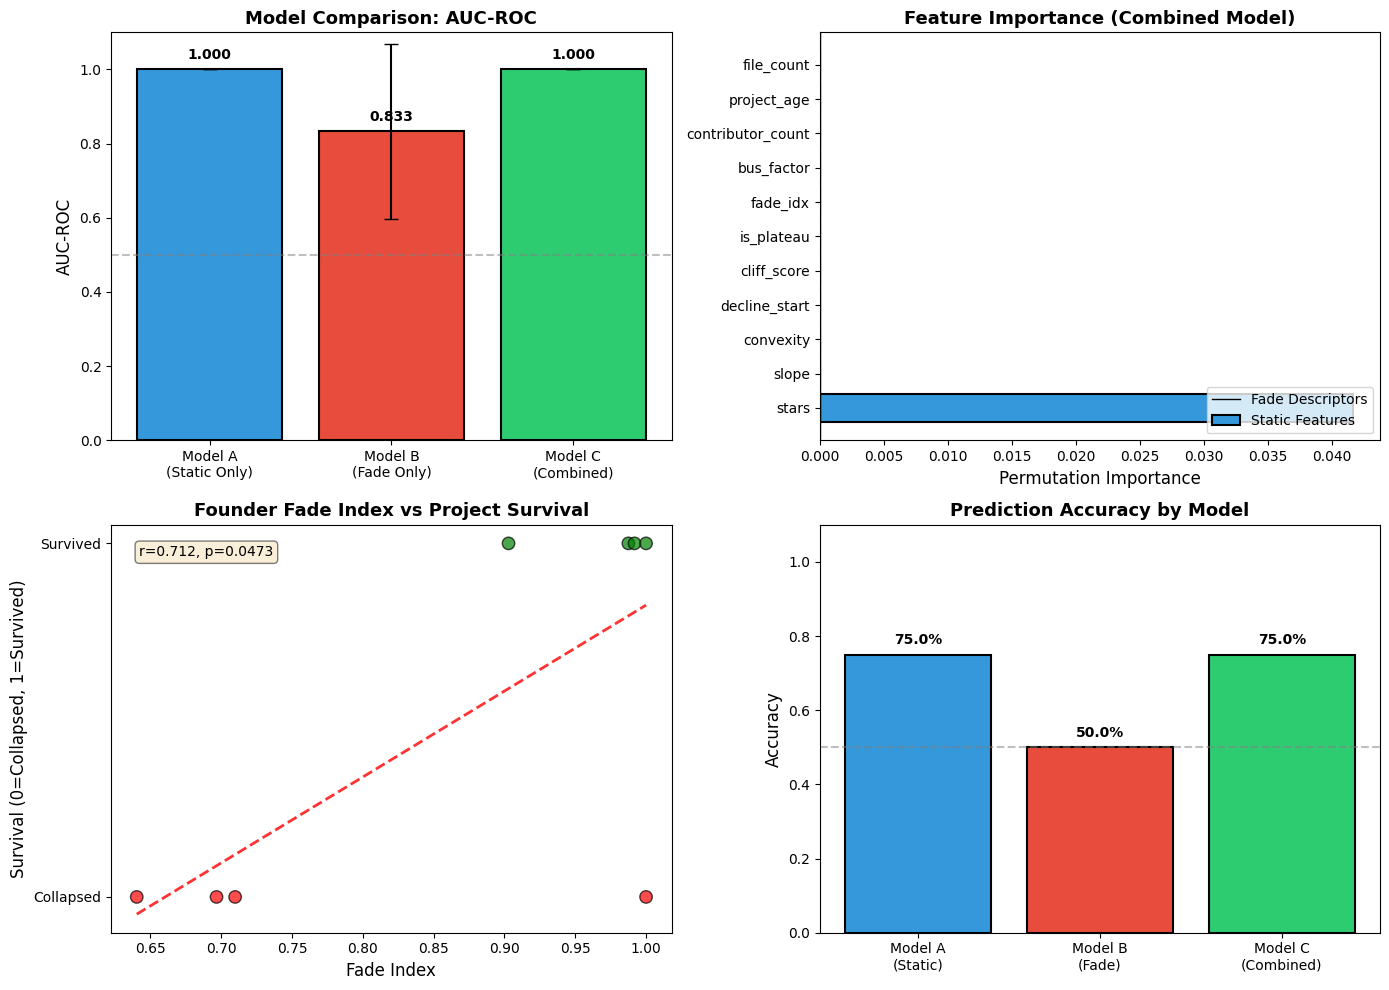


Visualization saved to experiment_results.png


In [9]:
# Print results summary
print("\n" + "=" * 60)
print("EXPERIMENT RESULTS SUMMARY")
print("=" * 60)
print(f"Total projects: {output['metadata']['n_projects']}")
print(f"Survived: {output['metadata']['n_survived']}, Collapsed: {output['metadata']['n_collapsed']}")
print(f"Model A (Static Only)    AUC: {output['metadata']['metrics']['model_a_auc']:.4f} ± {output['metadata']['metrics']['model_a_auc_std']:.4f}")
print(f"Model B (Fade Only)      AUC: {output['metadata']['metrics']['model_b_auc']:.4f} ± {output['metadata']['metrics']['model_b_auc_std']:.4f}")
print(f"Model C (Combined)       AUC: {output['metadata']['metrics']['model_c_auc']:.4f} ± {output['metadata']['metrics']['model_c_auc_std']:.4f}")
print(f"Model D (Continuous)     R2:  {output['metadata']['metrics']['model_d_r2']:.4f}")
print("-" * 60)
print(f"Directionality: {output['metadata']['directionality']}")
print(f"Falsification: {output['metadata']['falsification_result']}")
print("=" * 60)

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Model AUC comparison
ax1 = axes[0, 0]
model_names = ['Model A\n(Static Only)', 'Model B\n(Fade Only)', 'Model C\n(Combined)']
auc_values = [
    output['metadata']['metrics']['model_a_auc'],
    output['metadata']['metrics']['model_b_auc'],
    output['metadata']['metrics']['model_c_auc']
]
auc_errors = [
    output['metadata']['metrics']['model_a_auc_std'],
    output['metadata']['metrics']['model_b_auc_std'],
    output['metadata']['metrics']['model_c_auc_std']
]
colors = ['#3498db', '#e74c3c', '#2ecc71']
bars = ax1.bar(model_names, auc_values, yerr=auc_errors, capsize=5, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('AUC-ROC', fontsize=12)
ax1.set_title('Model Comparison: AUC-ROC', fontsize=13, fontweight='bold')
ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax1.set_ylim(0, 1.1)
for bar, val in zip(bars, auc_values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.3f}', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# 2. Feature Importance
ax2 = axes[0, 1]
importance = output['metadata']['feature_importance']
fade_imp = importance['fade_descriptors']
static_imp = importance['static_descriptors']
all_features_imp = {**fade_imp, **static_imp}
sorted_features = sorted(all_features_imp.items(), key=lambda x: x[1], reverse=True)
feat_names = [f[0] for f in sorted_features]
feat_values = [f[1] for f in sorted_features]
feat_colors = ['#e74c3c' if f in fade_imp else '#3498db' for f in feat_names]
bars2 = ax2.barh(feat_names, feat_values, color=feat_colors, edgecolor='black', linewidth=1.5)
ax2.set_xlabel('Permutation Importance', fontsize=12)
ax2.set_title('Feature Importance (Combined Model)', fontsize=13, fontweight='bold')
ax2.axvline(x=0, color='black', linestyle='-', linewidth=1)
legend_elements = ['Fade Descriptors', 'Static Features']
ax2.legend(['Fade Descriptors', 'Static Features'], loc='lower right')

# 3. Fade Index vs Survival
ax3 = axes[1, 0]
fade_idx_values = df_final['fade_idx'].values
survival_labels = df_final['is_survived'].values
colors_survival = ['red' if s == 0 else 'green' for s in survival_labels]
ax3.scatter(fade_idx_values, survival_labels, c=colors_survival, s=80, edgecolors='black', alpha=0.7)
ax3.set_xlabel('Fade Index', fontsize=12)
ax3.set_ylabel('Survival (0=Collapsed, 1=Survived)', fontsize=12)
ax3.set_title('Founder Fade Index vs Project Survival', fontsize=13, fontweight='bold')
ax3.set_yticks([0, 1])
ax3.set_yticklabels(['Collapsed', 'Survived'])
# Add trend line
z = np.polyfit(fade_idx_values, survival_labels, 1)
p = np.poly1d(z)
x_line = np.linspace(min(fade_idx_values), max(fade_idx_values), 100)
ax3.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2)
corr, p_val = pointbiserialr(fade_idx_values, survival_labels)
ax3.text(0.05, 0.95, f'r={corr:.3f}, p={p_val:.4f}', transform=ax3.transAxes, 
         fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 4. Prediction Accuracy
ax4 = axes[1, 1]
examples = output['datasets'][0]['examples']
true_labels = [1 if json.loads(e['output'])['survival'] == 'survive' else 0 for e in examples]
pred_static = [1 if e['predict_baseline_static'] == 'survive' else 0 for e in examples]
pred_fade = [1 if e['predict_fade_only'] == 'survive' else 0 for e in examples]
pred_combined = [1 if e['predict_combined'] == 'survive' else 0 for e in examples]

correct_static = sum(1 for t, p in zip(true_labels, pred_static) if t == p)
correct_fade = sum(1 for t, p in zip(true_labels, pred_fade) if t == p)
correct_combined = sum(1 for t, p in zip(true_labels, pred_combined) if t == p)

accuracy_models = ['Model A\n(Static)', 'Model B\n(Fade)', 'Model C\n(Combined)']
accuracy_values = [correct_static/len(examples), correct_fade/len(examples), correct_combined/len(examples)]
bars3 = ax4.bar(accuracy_models, accuracy_values, color=colors, edgecolor='black', linewidth=1.5)
ax4.set_ylabel('Accuracy', fontsize=12)
ax4.set_title('Prediction Accuracy by Model', fontsize=13, fontweight='bold')
ax4.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax4.set_ylim(0, 1.1)
for bar, val in zip(bars3, accuracy_values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.1%}', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('experiment_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nVisualization saved to experiment_results.png")